# Assignment 1: Housing Price Prediction
**Group 26:** Matteo Castelli, Haakon Torvik Gullbekk, Marius Alexander Langaas Klæbo, Jørund Birkeland

We use the supplied Ames Housing data to predict sale prices. We explore the data, split it into training and test sets, prepare the variables, and compare three regression models.


## 1. Load the data
We start by checking the columns, data types and first rows.


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("AmesHousing.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("AmesHousing.csv was not found. Put it in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset path: AmesHousing.csv
Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.000,Unf,0.000,441.000,"1,080.000",GasA,Fa,Y,SBrkr,1656,0,0,1656,1.000,0.000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.000",Fin,2.000,528.000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.000,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.000,Gd,TA,CBlock,TA,TA,No,ALQ,"1,065.000",Unf,0.000,"1,045.000","2,110.000",GasA,Ex,Y,SBrkr,2110,0,0,2110,1.000,0.000,2,1,3,1,Ex,8,Typ,2,TA,Attchd,"1,968.000",Fin,2.000,522.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
# Data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

### Overview
The table below shows summary statistics for each column.


In [3]:
# Descriptive overview
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,"2,930.000",NaN,NaN,NaN,"1,465.500",845.962,1.000,733.250,"1,465.500","2,197.750","2,930.000"
PID,"2,930.000",NaN,NaN,NaN,"714,464,496.989","188,730,844.649","526,301,100.000","528,477,022.500","535,453,620.000","907,181,097.500","1,007,100,110.000"
MS SubClass,"2,930.000",NaN,NaN,NaN,57.387,42.638,20.000,20.000,50.000,70.000,190.000
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,"2,440.000",NaN,NaN,NaN,69.225,23.365,21.000,58.000,68.000,80.000,313.000
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,"2,930.000",NaN,NaN,NaN,6.216,2.714,1.000,4.000,6.000,8.000,12.000
Yr Sold,"2,930.000",NaN,NaN,NaN,"2,007.790",1.317,"2,006.000","2,007.000","2,008.000","2,009.000","2,010.000"
Sale Type,2930,10,WD,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2930,6,Normal,2413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### What is in the dataset?
There are 2,930 sales and 82 columns. SalePrice is what we want to predict. The other columns include numbers, categories, years and some missing values.

MS SubClass looks numerical, but its values are codes for house types. We treat it as a category later.


## 2. Explore the data
### 2.1 Sale prices


count     2,930.000
mean    180,796.060
std      79,886.692
min      12,789.000
25%     129,500.000
50%     160,000.000
75%     213,500.000
max     755,000.000
Name: SalePrice, dtype: float64

Skewness: 1.744


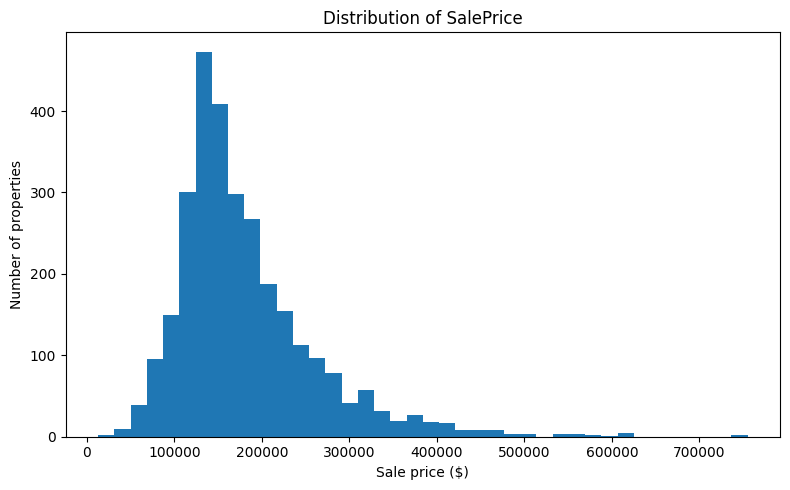

In [4]:
print(df["SalePrice"].describe())
print(f"\nSkewness: {df['SalePrice'].skew():.3f}")

plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=40)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale price ($)")
plt.ylabel("Number of properties")
plt.tight_layout()
plt.show()

SalePrice is right-skewed. Most houses cost much less than the most expensive ones. We keep prices in dollars so RMSE is easy to interpret.


### 2.2 Missing values
The dataset guide says missing can mean two different things. A blank Pool QC usually means there is no pool, while a blank Lot Frontage means the measurement is unknown. We handle these cases differently.


In [5]:
missing = (
    df.isna()
      .sum()
      .to_frame("Missing")
      .assign(Percent=lambda x: 100 * x["Missing"] / len(df))
      .query("Missing > 0")
      .sort_values("Percent", ascending=False)
)

missing.head(20)

,Missing,Percent
Pool QC,2917,99.556
Misc Feature,2824,96.382
Alley,2732,93.242
Fence,2358,80.478
Mas Vnr Type,1775,60.580
Fireplace Qu,1422,48.532
Lot Frontage,490,16.724
Garage Qual,159,5.427
Garage Cond,159,5.427
Garage Yr Blt,159,5.427


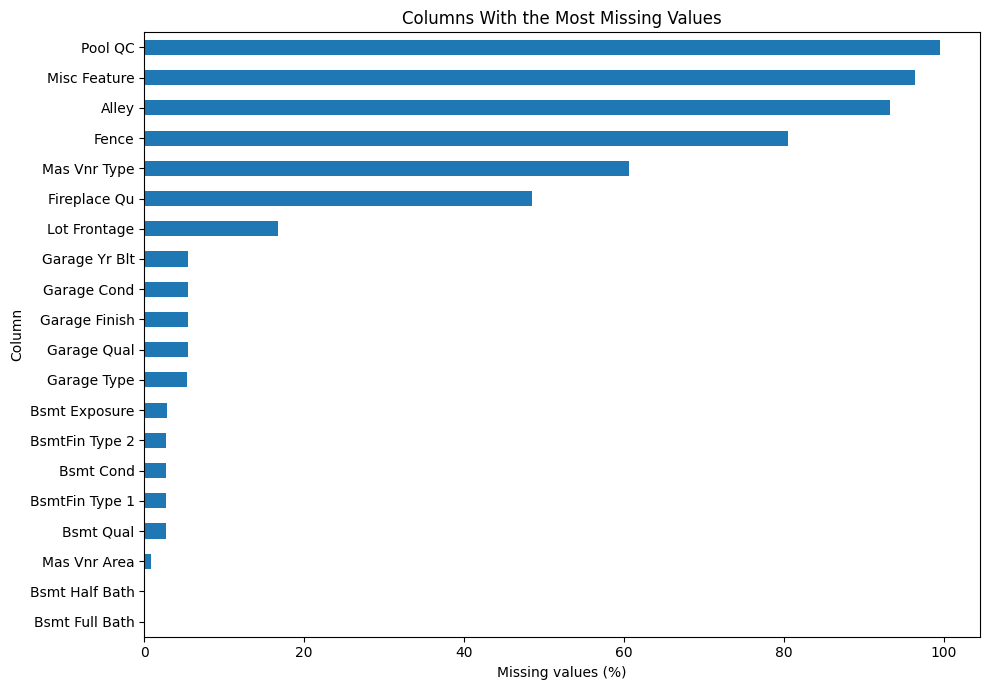

In [6]:
plt.figure(figsize=(10, 7))
missing.head(20)["Percent"].sort_values().plot(kind="barh")
plt.title("Columns With the Most Missing Values")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

Columns with many missing values can still be useful. For Pool QC, Fireplace Qu and Alley, a blank usually means the feature is absent. Lot Frontage is different: its missing values are unknown measurements.


## 3. Training and test sets
We remove Order and PID because they are identifiers. We then split the data 80/20. After this point, we use the training set to make modelling decisions and keep the test set for the final comparison.


In [7]:
X = df.drop(columns=["SalePrice", "Order", "PID"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 2344
Test observations: 586


If we used the test set to choose features or preprocessing, the final scores would be less trustworthy. That is why we leave it aside until evaluation.


## 4. Relationships in the training data
We add SalePrice back to a copy of the training features for the plots and summaries below.


In [8]:
train_eda = X_train.copy()
train_eda["SalePrice"] = y_train

### 4.1 Numerical correlations
Correlations help us see which numerical variables may be useful. They do not capture every type of relationship, so we do not use them as the only reason to keep or remove a variable.


In [9]:
numeric_corr = (
    train_eda
    .select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)

numeric_corr.head(15)

Overall Qual     0.795
Gr Liv Area      0.698
Garage Cars      0.644
Garage Area      0.633
Total Bsmt SF    0.612
1st Flr SF       0.607
Year Built       0.545
Full Bath        0.542
Year Remod/Add   0.518
Garage Yr Blt    0.516
Mas Vnr Area     0.491
TotRms AbvGrd    0.475
Fireplaces       0.468
BsmtFin SF 1     0.424
Wood Deck SF     0.333
Name: SalePrice, dtype: float64

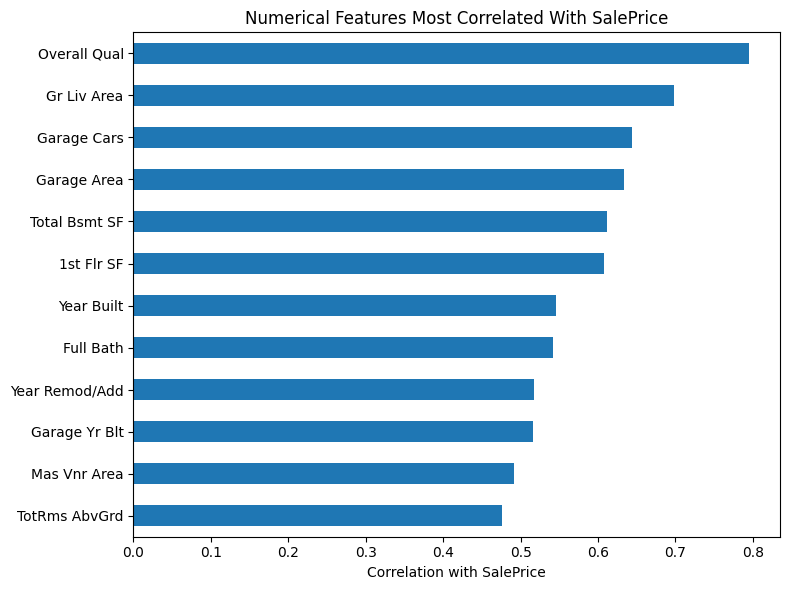

In [10]:
top_corr = numeric_corr.head(12).sort_values()

plt.figure(figsize=(8, 6))
top_corr.plot(kind="barh")
plt.title("Numerical Features Most Correlated With SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.tight_layout()
plt.show()

Overall Qual and Gr Liv Area have the strongest correlations with SalePrice. Garage size, basement size, first-floor area and year variables also stand out.


### 4.2 Overall quality


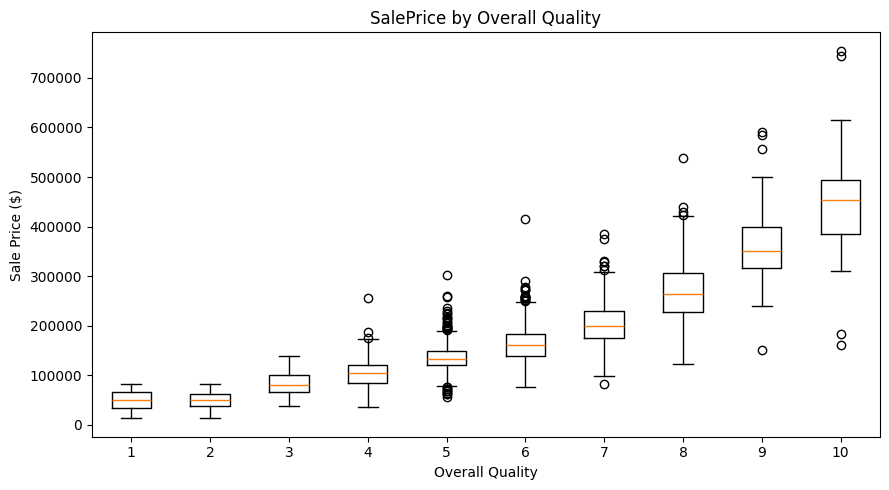

In [11]:
quality_levels = sorted(train_eda["Overall Qual"].dropna().unique())
quality_prices = [
    train_eda.loc[train_eda["Overall Qual"] == level, "SalePrice"].values
    for level in quality_levels
]

plt.figure(figsize=(9, 5))
plt.boxplot(quality_prices, tick_labels=quality_levels)
plt.title("SalePrice by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

Prices rise clearly with Overall Qual, so quality should be useful for prediction.


### 4.3 Living area and unusual houses


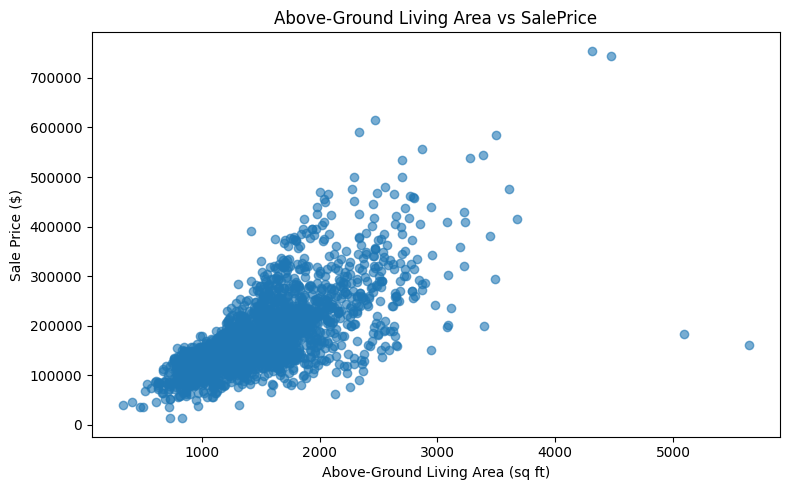

Very large training-set properties:


,Gr Liv Area,SalePrice
1498,5642,160000
2180,5095,183850


In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(train_eda["Gr Liv Area"], train_eda["SalePrice"], alpha=0.6)
plt.title("Above-Ground Living Area vs SalePrice")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

print("Very large training-set properties:")
display(train_eda.loc[train_eda["Gr Liv Area"] > 5000, ["Gr Liv Area", "SalePrice"]])

Larger homes usually sell for more, but a few very large homes sold for less than the general pattern suggests. We keep them because we have no reason to call them data errors.


### 4.4 Categories
We also look at Neighborhood, Kitchen Qual and Exter Qual. These would not appear in a numerical correlation table.


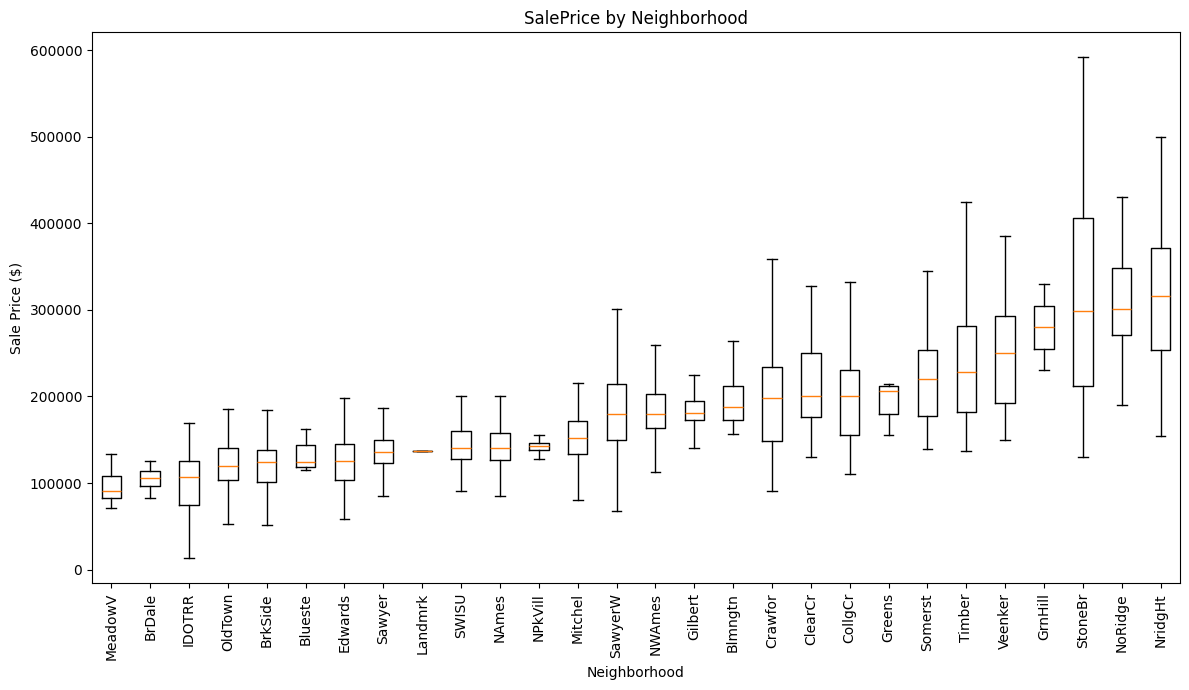

In [13]:
neighborhood_order = (
    train_eda.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values()
    .index
)

neighborhood_prices = [
    train_eda.loc[train_eda["Neighborhood"] == n, "SalePrice"].values
    for n in neighborhood_order
]

plt.figure(figsize=(12, 7))
plt.boxplot(neighborhood_prices, tick_labels=neighborhood_order, showfliers=False)
plt.xticks(rotation=90)
plt.title("SalePrice by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

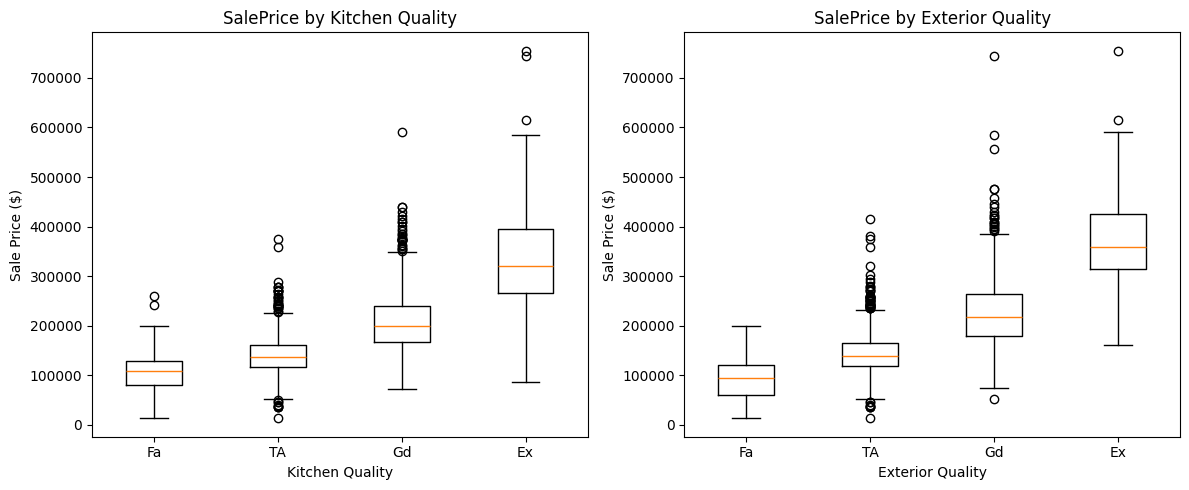

Neighborhood median price range:
min    90,750.000
max   316,000.000
Name: SalePrice, dtype: float64

Kitchen quality median prices:
Kitchen Qual
Fa   108,500.000
TA   137,000.000
Gd   200,000.000
Ex   320,000.000
Name: SalePrice, dtype: float64

Exterior quality median prices:
Exter Qual
Fa    93,775.000
TA   139,500.000
Gd   216,500.000
Ex   357,950.000
Name: SalePrice, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

kitchen_levels = ["Fa", "TA", "Gd", "Ex"]
kitchen_prices = [
    train_eda.loc[train_eda["Kitchen Qual"] == level, "SalePrice"].values
    for level in kitchen_levels
    if level in train_eda["Kitchen Qual"].dropna().unique()
]
kitchen_labels = [level for level in kitchen_levels if level in train_eda["Kitchen Qual"].dropna().unique()]
axes[0].boxplot(kitchen_prices, tick_labels=kitchen_labels)
axes[0].set_title("SalePrice by Kitchen Quality")
axes[0].set_xlabel("Kitchen Quality")
axes[0].set_ylabel("Sale Price ($)")

exter_levels = ["Fa", "TA", "Gd", "Ex"]
exter_prices = [
    train_eda.loc[train_eda["Exter Qual"] == level, "SalePrice"].values
    for level in exter_levels
    if level in train_eda["Exter Qual"].dropna().unique()
]
exter_labels = [level for level in exter_levels if level in train_eda["Exter Qual"].dropna().unique()]
axes[1].boxplot(exter_prices, tick_labels=exter_labels)
axes[1].set_title("SalePrice by Exterior Quality")
axes[1].set_xlabel("Exterior Quality")
axes[1].set_ylabel("Sale Price ($)")

plt.tight_layout()
plt.show()

print("Neighborhood median price range:")
print(train_eda.groupby("Neighborhood")["SalePrice"].median().agg(["min", "max"]))

print("\nKitchen quality median prices:")
print(train_eda.groupby("Kitchen Qual")["SalePrice"].median().sort_values())

print("\nExterior quality median prices:")
print(train_eda.groupby("Exter Qual")["SalePrice"].median().sort_values())

Prices differ across neighborhoods and quality levels. We therefore keep categorical features and encode them for the models.


## 5. Prepare the features
We first apply rules from the dataset guide, such as marking a missing fireplace quality as no fireplace. The imputation, encoding and scaling steps are fitted on the training set inside a pipeline.


In [15]:
def prepare_features(X):
    """Apply deterministic semantic cleaning and feature engineering.

    This function does not learn statistics from X; it applies the same
    meaning-based rules to both training and test sets.
    """
    X = X.copy()

    # Numeric-looking codes/categories should not be treated as continuous measurements.
    X["MS SubClass"] = X["MS SubClass"].astype(str)
    X["Mo Sold"] = X["Mo Sold"].astype(str)

    # Missing explicitly means the feature is absent according to the supplied guide.
    absent_features = [
        "Alley",
        "Fireplace Qu",
        "Pool QC",
        "Fence",
        "Misc Feature"
    ]
    for col in absent_features:
        X[col] = X[col].fillna("None")

    # Masonry veneer: distinguish "none" from "type unknown" using veneer area.
    missing_masonry = X["Mas Vnr Type"].isna()
    X.loc[
        missing_masonry & X["Mas Vnr Area"].eq(0),
        "Mas Vnr Type"
    ] = "None"
    X.loc[
        missing_masonry & ~X["Mas Vnr Area"].eq(0),
        "Mas Vnr Type"
    ] = "Unknown"

    # Basement categories: if total basement area is 0, absence is meaningful.
    basement_categories = [
        "Bsmt Qual",
        "Bsmt Cond",
        "Bsmt Exposure",
        "BsmtFin Type 1",
        "BsmtFin Type 2"
    ]
    no_basement = X["Total Bsmt SF"].eq(0)
    for col in basement_categories:
        missing = X[col].isna()
        X.loc[missing & no_basement, col] = "None"
        X.loc[missing & ~no_basement, col] = "Unknown"

    # Garage categories: use area/capacity to distinguish no garage from unknown detail.
    garage_categories = [
        "Garage Type",
        "Garage Finish",
        "Garage Qual",
        "Garage Cond"
    ]
    no_garage = X["Garage Area"].eq(0) | X["Garage Cars"].eq(0)
    for col in garage_categories:
        missing = X[col].isna()
        X.loc[missing & no_garage, col] = "None"
        X.loc[missing & ~no_garage, col] = "Unknown"

    # Interpretable engineered features.
    X["HouseAge"] = X["Yr Sold"] - X["Year Built"]
    X["RemodAge"] = X["Yr Sold"] - X["Year Remod/Add"]

    X["TotalSF"] = X[
        ["Total Bsmt SF", "1st Flr SF", "2nd Flr SF"]
    ].sum(axis=1, min_count=3)

    X["TotalBathrooms"] = (
        X["Full Bath"]
        + 0.5 * X["Half Bath"]
        + X["Bsmt Full Bath"]
        + 0.5 * X["Bsmt Half Bath"]
    )

    porch_columns = [
        "Wood Deck SF",
        "Open Porch SF",
        "Enclosed Porch",
        "3Ssn Porch",
        "Screen Porch"
    ]
    X["TotalOutdoorSF"] = X[porch_columns].sum(axis=1)

    return X


X_train_prepared = prepare_features(X_train)
X_test_prepared = prepare_features(X_test)

print("Prepared training shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)

Prepared training shape: (2344, 84)
Prepared test shape: (586, 84)


### Feature choices
We keep the house and sale characteristics but remove the two identifiers, Order and PID. We also add five features:

- HouseAge = Yr Sold - Year Built
- RemodAge = Yr Sold - Year Remod/Add
- TotalSF = Total Bsmt SF + 1st Flr SF + 2nd Flr SF
- TotalBathrooms, counting half bathrooms as 0.5
- TotalOutdoorSF, adding deck and porch areas

We keep the original columns too. A variable with a weak correlation may still help a model when used with other variables.


### 5.1 Numerical and categorical columns
We identify the column types from the prepared training set.


In [16]:
numeric_features = (
    X_train_prepared
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train_prepared
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 39
Categorical features: 45


In [17]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

We fill unknown numerical values with the training median. For categories, we use the most common training value when needed and then one-hot encode the columns. `handle_unknown="ignore"` lets the model accept a category it did not see during training.

We scale numerical columns for Linear Regression. Trees do not need scaling, but we use the same prepared features for all three models to compare them fairly. The pipeline learns these values from the training set only.


## 6. Train the models
We train the three models named in the assignment without tuning their settings.


In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}
predictions_by_model = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])

    pipeline.fit(X_train_prepared, y_train)
    predictions = pipeline.predict(X_test_prepared)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R²": r2
    })

    fitted_models[model_name] = pipeline
    predictions_by_model[model_name] = predictions

results_df = pd.DataFrame(results)
results_df

,Model,Test RMSE,Test R²
0,Linear Regression,"29,087.892",0.894
1,Decision Tree Regression,"39,192.967",0.808
2,Random Forest Regression,"25,201.794",0.921


## 7. Test results
RMSE is the typical size of the error in dollars, with larger errors counting more. Lower is better. R² compares the model with predicting the average price for every house. Higher is better; it is not percentage accuracy.


In [19]:
results_display = results_df.copy()
results_display["Test RMSE"] = results_display["Test RMSE"].round(0).astype(int)
results_display["Test R²"] = results_display["Test R²"].round(3)
results_display

,Model,Test RMSE,Test R²
0,Linear Regression,29088,0.894
1,Decision Tree Regression,39193,0.808
2,Random Forest Regression,25202,0.921


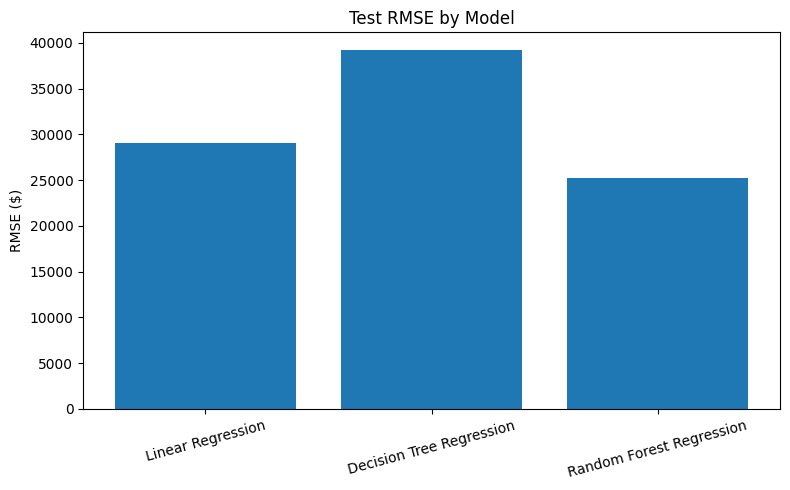

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test RMSE"])
plt.title("Test RMSE by Model")
plt.ylabel("RMSE ($)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

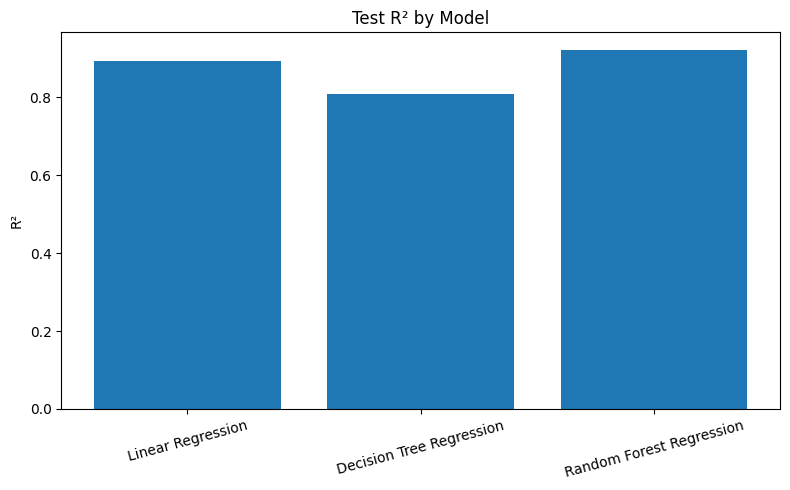

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test R²"])
plt.title("Test R² by Model")
plt.ylabel("R²")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Random Forest performs best on this test set: it has the lowest RMSE and highest R². Its RMSE is still about $25,000, so the predictions can be quite far from the actual price.


### 7.1 Actual and predicted prices


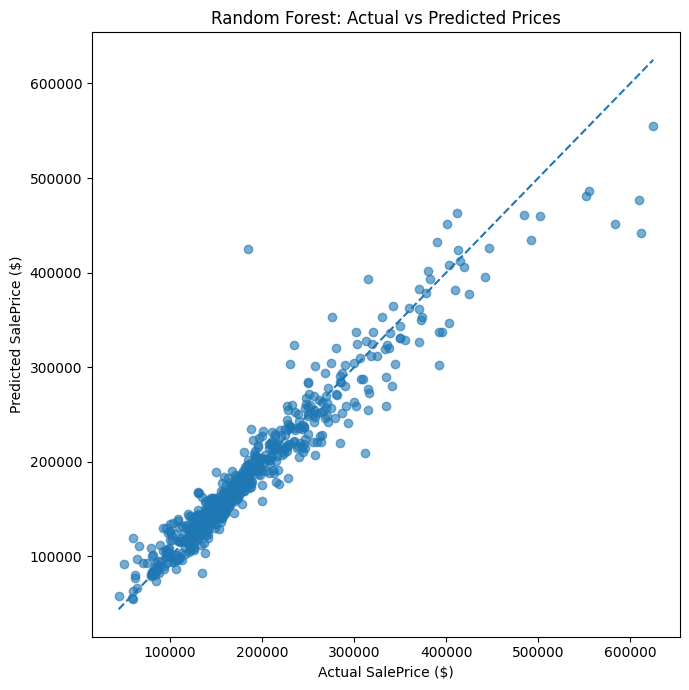

In [22]:
rf_predictions = predictions_by_model["Random Forest Regression"]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_predictions, alpha=0.6)

minimum = min(y_test.min(), rf_predictions.min())
maximum = max(y_test.max(), rf_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

Most points follow the diagonal, but some houses have larger errors, especially at higher prices.
